# Fig. — Clutter suppression (κ sweep)

Loader/summary helpers come from `build_fig_clutter.py`; **`build_figure` is inlined
below as an editable cell** so you can override style without editing the module.

- **(top)** SINR vs κ (communication cost). `SINR_METRIC`: `'min'` (min-user SINR)
  or `'mean'` (mean-user SINR).
- **(bottom)** SCNR vs κ (the suppression). `SCNR_METRIC`: `'wsum'` (weighted-sum
  SCNR, **default**), `'min'` (min-target SCNR), or `'mean'` (mean-target SCNR).
- `BAND`: `'std'` (mean±std, **default**), `'iqr'` (25–75 pct), or `'none'`.
- Dashed line marks the deployed operating point κ\* (= `ADMM_KAPPA`, 0.08).

**Compatible experiment:** `kappa_sweep` (`kind=='sweep'`); needs the *offset* clutter
geometry (the recipe default) for SCNR to actually climb with κ.

In [1]:
import sys, logging
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

FIG_DIR = Path.cwd()
if str(FIG_DIR) not in sys.path:
    sys.path.insert(0, str(FIG_DIR))

import build_fig_clutter as B   # loader + helpers (single source of truth)
from cordis.plotting import apply_paper_style, figsize, plot_sweep, save_figure
from cordis.plotting.style import ALGORITHM_STYLE   # tweak here to restyle

USE_TEX = True   # set False on a node without pdflatex
apply_paper_style()
logging.basicConfig(level=logging.INFO, format='%(levelname)-7s %(message)s')

## 1. Load the κ-sweep run

In [2]:
RESULT_DIR = None   # e.g. 'results/exp_kappa_sweep/array_12345_aggregated'
result, result_dir = B.load_sweep(RESULT_DIR, experiment='kappa_sweep')
print('run:', result_dir)
print('κ grid:', sorted(result.sweep_results.keys()))

run: /Users/mehdi/Local-Drive/GitHub/CORDIS/results/exp_kappa_sweep/array_52882020_aggregated
κ grid: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 1.0, 2.0]


## 2. Knobs: metrics, band, operating point

In [3]:
SINR_METRIC = 'min'    # 'min' (min-user SINR) | 'mean' (mean-user SINR)
SCNR_METRIC = 'wsum'   # 'wsum' (weighted-sum) | 'min' (min-target) | 'mean' (mean-target)
BAND        = 'std'    # 'std' | 'iqr' | 'none'
KAPPA_STAR  = 0.08     # deployed operating point (marked)
ONLY        = list(B.PREFERRED)

only = B._present_algorithms(result, ONLY)
sinr_name, _ = B._resolve_sinr_metric(SINR_METRIC)
scnr_name, _, _ = B._resolve_scnr_metric(SCNR_METRIC, result, only)
print('algorithms:', only)
print('SINR metric:', sinr_name, '| SCNR metric:', scnr_name, '| band:', BAND)

algorithms: ['Centralized', 'CORDIS-ADMM', 'CORDIS-Split']
SINR metric: min_sinr_db | SCNR metric: weighted_sum_scnr_db | band: std


## 3. Numeric summary (caption sanity check)

Suppression gain = SCNR(κ_max) − SCNR(κ_min); comm cost = SINR(κ\*) − SINR(κ_min).

In [4]:
summary = B.collect_summary(result, only, sinr_name, scnr_name, KAPPA_STAR)
B._print_summary(result, summary, sinr_name, scnr_name, KAPPA_STAR)

[info] κ grid     = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 1.0, 2.0]
[info] κ* (marked)= 0.08  (nearest swept point 0.1)
[info] SINR metric= min_sinr_db
[info] SCNR metric= weighted_sum_scnr_db
algorithm      SCNR κmin  SCNR κ* SCNR κmax    gain  SINR κ* SINR cost
----------------------------------------------------------------------
Centralized        47.25    50.31     49.55    2.30     5.00     -0.00
CORDIS-ADMM        47.15    48.27     50.22    3.07     4.98     -0.02
CORDIS-Split       41.65    42.56     42.56    0.91     5.01     -8.03


## 4. `build_figure` — editable copy

The **exact** function from `build_fig_clutter.py`, inlined so you can edit it and
re-run. Mutate `ALGORITHM_STYLE` in the setup cell to restyle without editing the body.

In [5]:
# Bind the module-level names the function body references.
from typing import Optional, Sequence
PREFERRED            = B.PREFERRED
SINR_METRIC_DEFAULT  = B.SINR_METRIC_DEFAULT
SCNR_METRIC_DEFAULT  = B.SCNR_METRIC_DEFAULT
BAND_DEFAULT         = B.BAND_DEFAULT
KAPPA_STAR_DEFAULT   = B.KAPPA_STAR_DEFAULT
_present_algorithms  = B._present_algorithms
_resolve_sinr_metric = B._resolve_sinr_metric
_resolve_scnr_metric = B._resolve_scnr_metric
logger               = logging.getLogger('fig_clutter.nb')

In [68]:
def build_figure(result,
                 *,
                 only: Optional[Sequence[str]] = None,
                 sinr_metric: str = SINR_METRIC_DEFAULT,
                 scnr_metric: str = SCNR_METRIC_DEFAULT,
                 band: str = BAND_DEFAULT,
                 kappa_star: float = KAPPA_STAR_DEFAULT,
                 log_x: bool = False,
                 use_tex: bool = True):
    """Assemble the stacked κ-sweep figure and return
    ``(fig, only, scnr_metric_name)``.

    ``sinr_metric`` is 'min'|'mean'; ``scnr_metric`` is 'min'|'mean'|'wsum';
    ``band`` is 'std'|'iqr'|'none' (the dispersion shading around each mean
    curve).  Built directly on ``cordis.plotting.plot_sweep``.
    """
    import matplotlib
    if use_tex is False:
        matplotlib.rcParams["text.usetex"] = False
    import matplotlib.pyplot as plt
    from cordis.plotting import apply_paper_style, figsize, plot_sweep

    apply_paper_style()
    if use_tex is False:
        matplotlib.rcParams["text.usetex"] = False

    # IEEE standard font sizes
    IEEE_FONT_SIZE = 9
    plt.rcParams.update({
        "font.size": IEEE_FONT_SIZE,
        "axes.labelsize": IEEE_FONT_SIZE + 2,
        "xtick.labelsize": IEEE_FONT_SIZE,
        "ytick.labelsize": IEEE_FONT_SIZE,
        "legend.fontsize": IEEE_FONT_SIZE,
        "legend.title_fontsize": IEEE_FONT_SIZE,
        "figure.titlesize": IEEE_FONT_SIZE,
        "axes.titlesize": IEEE_FONT_SIZE,
    })
    LW = 2
    MARKER_SIZE = 6
    ADD_KAPPA_STAR = False

    only = list(only) if only else _present_algorithms(result, PREFERRED)
    sinr_name, sinr_label = _resolve_sinr_metric(sinr_metric)
    scnr_name, scnr_full, _scnr_short = _resolve_scnr_metric(scnr_metric, result, only)

    axis = result.sweep_axis
    if log_x and 0.0 in result.sweep_results:
        logger.warning("log_x requested but κ=0 is in the grid; using linear x.")
        log_x = False

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=figsize(width="double", aspect=4 / 3),
        sharex=True, gridspec_kw={"hspace": 0.12},
    ) # aspect= 3.5 / 2.6

    # (top) SINR vs κ  — communication cost
    plot_sweep(result.sweep_results, metric=sinr_name, ax=ax_top, error=band,
               xlabel="", ylabel=f"{sinr_label} [dB]", only=only, log_x=log_x)
    # ax_top.set_title(r"Clutter suppression vs penalty $\kappa$")

    # (bot) SCNR vs κ  — sensing benefit (the suppression)
    if scnr_name is not None:
        plot_sweep(result.sweep_results, metric=scnr_name, ax=ax_bot, error=band,
                   xlabel=axis.display or r"$\kappa$",
                   ylabel=f"{scnr_full} [dB]", only=only, log_x=log_x)
    else:
        logger.warning("No SCNR metric available; bottom panel left empty.")
        ax_bot.set_xlabel(axis.display or r"$\kappa$")

    # operating-point marker κ* on both panels (label once, on top).
    # get_xaxis_transform() = (data-x, axes-y); tight_layout-safe.
    for ax in (ax_top, ax_bot):
        if ADD_KAPPA_STAR:
            ax.axvline(kappa_star, ls="--", lw=1, color="0.45", zorder=0)
        for line in ax.lines:
            line.set_markersize(MARKER_SIZE)      # Change marker size
            line.set_linewidth(LW)
    if ADD_KAPPA_STAR:
        ax_top.text(kappa_star*1.2, 0.96, r"$\kappa^\star$",
                    transform=ax_top.get_xaxis_transform(),
                    ha="left", va="top", fontsize=12, color="0.35")

    # one legend only (top); drop the duplicate on the bottom panel
    if ax_bot.get_legend() is not None:
        ax_bot.get_legend().remove()

    # NB: no fig.tight_layout() — it conflicts with the shared-x / hspace
    # stacked layout (same reason scripts/_plot_common.sweep_plot_pair omits
    # it).  save_figure() uses bbox_inches='tight', which handles the margins.
    return fig, only, scnr_name


## 5. Render

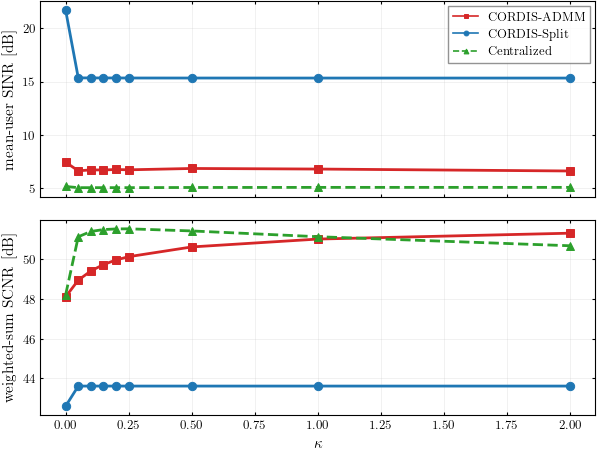

In [70]:
fig, used_only, used_scnr_metric = build_figure(
    result, only=only, sinr_metric='mean', scnr_metric='wsum',
    band='none', kappa_star=KAPPA_STAR, use_tex=USE_TEX,
)
plt.show()

## 6. Save to `paper/figures/`

In [71]:
tag = ''
out_stem = FIG_DIR.parents[1] / 'figures' / str('fig_clutter' + tag)
paths = save_figure(
    fig, out_stem, formats=('pdf','png'),
    metadata={
        'Figure': 'fig_clutter', 'KappaStar': f'{KAPPA_STAR:g}',
        'SinrMetric': sinr_name, 'ScnrMetric': str(used_scnr_metric), 'Band': BAND,
        'Algorithms': ', '.join(used_only), 'Run': result_dir.name,
    },
)
for p in paths:
    print('wrote', p)

wrote /Users/mehdi/Local-Drive/GitHub/CORDIS/paper/figures/fig_clutter.pdf
wrote /Users/mehdi/Local-Drive/GitHub/CORDIS/paper/figures/fig_clutter.png
